# 🎬 Análisis de Comentarios positivos o negativos de YouTube


## 1. 📦 Carga de Librerías

In [2]:
!apt-get update -q
!apt-get install -y chromium-browser chromium-driver -q
!pip install selenium beautifulsoup4 textblob wordcloud --quiet
!python -m textblob.download_corpora --quiet

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,936 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,880 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,794 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,615 kB]
Get:14 http://securit

In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
import time
from bs4 import BeautifulSoup
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter


import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


In [4]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb -q
!pip install webdriver-manager --quiet

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 7 not upgraded.
Need to get 11.2 MB/139 MB of archives.
After this operation, 467 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatspi2.0-0 a

## 2. ⬇️ Descargar Comentarios con Selenium + BeautifulSoup

In [5]:
import subprocess
version = subprocess.getoutput('google-chrome --version')

import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

URL             = 'https://www.youtube.com/watch?v=TaQj43Lf3tw'
MAX_COMENTARIOS = 200
SCROLLS         = 20

def crear_driver():
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_argument('--window-size=1920,1080')
    options.add_argument('--lang=es-MX')
    options.add_argument(
        'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
    driver_path = ChromeDriverManager().install()
    print(f'✅ ChromeDriver: {driver_path}')
    return webdriver.Chrome(service=Service(driver_path), options=options)


def obtener_comentarios_selenium(url, max_total=200, n_scrolls=20):
    """
    Selenium carga YouTube y hace scroll para renderizar comentarios.
    BeautifulSoup parsea el HTML resultante y extrae cada comentario.
    """
    print('⏳ Abriendo YouTube con Selenium...')
    driver = crear_driver()

    try:
        driver.get(url)
        time.sleep(5)

        driver.execute_script('window.scrollTo(0, 700);')
        time.sleep(3)

        print(f'🔄 Haciendo {n_scrolls} scrolls...')
        for i in range(n_scrolls):
            driver.execute_script('window.scrollBy(0, 900);')
            time.sleep(1.8)
            if (i + 1) % 5 == 0:
                print(f'   scroll {i+1}/{n_scrolls}...')

        html = driver.page_source

    finally:
        driver.quit()

    soup = BeautifulSoup(html, 'html.parser')

    selectores = [
        'yt-attributed-string#content-text span',
        'ytd-comment-renderer #content-text',
        '#content-text span',
        '#content-text',
    ]

    elementos = []
    for sel in selectores:
        elementos = soup.select(sel)
        if elementos:
            print(f'   ✅ Selector: "{sel}" → {len(elementos)} elementos')
            break

    if not elementos:
        print('   ⚠️ Sin comentarios. Sube SCROLLS a 30 e intenta de nuevo.')
        return []

    comentarios, vistos = [], set()
    for el in elementos:
        texto = el.get_text(separator=' ', strip=True)
        if texto and texto not in vistos and len(texto) > 5:
            comentarios.append(texto)
            vistos.add(texto)
        if len(comentarios) >= max_total:
            break

    print(f'✅ {len(comentarios)} comentarios extraídos con BeautifulSoup.')
    return comentarios


comentarios_raw = obtener_comentarios_selenium(URL, MAX_COMENTARIOS, SCROLLS)

print('\n🔍 Muestra — primeros 5 comentarios:')
for c in comentarios_raw[:5]:
    print(f'  • {c[:120]}')


⏳ Abriendo YouTube con Selenium...
✅ ChromeDriver: /root/.wdm/drivers/chromedriver/linux64/146.0.7680.153/chromedriver-linux64/chromedriver
🔄 Haciendo 20 scrolls...
   scroll 5/20...
   scroll 10/20...
   scroll 15/20...
   scroll 20/20...
   ✅ Selector: "yt-attributed-string#content-text span" → 343 elementos
✅ 122 comentarios extraídos con BeautifulSoup.

🔍 Muestra — primeros 5 comentarios:
  • ¿Quién más en 2026 volviendo a escuchar este temazo y por nostalgia? Yo aún recuerdo cuando esta canción acababa de sali
  • Que prefieres:
La musica de bad bunny: comenta
La musica de mike: like
Pd: gracias por los likes nunca me senti tan famo
  • Al 1% que esté viendo este comentario quiero desearle un feliz día

Edit: nunca pensé que tendría tantos likes, gracias 
  • Volví después de 5 años
  • Cuántas vistas llegará mikecrack
10 millones: 100 likes
30 millones: 300 likes
50 millones: 500 likes


## 3. 🗂️ Carga de Datos y Clasificación de Sentimientos

In [6]:
df = pd.DataFrame({'comentario': comentarios_raw})

def clasificar(texto):
    return 'Positivo' if TextBlob(texto).sentiment.polarity > 0 else 'Negativo'

df['sentimiento'] = df['comentario'].apply(clasificar)

print('📊 Distribución de sentimientos:')
print(df['sentimiento'].value_counts().to_string())
print(f'\nTotal de comentarios: {len(df)}')
df.head(10)

📊 Distribución de sentimientos:
sentimiento
Negativo    110
Positivo     12

Total de comentarios: 122


,comentario,sentimiento
0,¿Quién más en 2026 volviendo a escuchar este t...,Negativo
1,Que prefieres:\nLa musica de bad bunny: coment...,Negativo
2,Al 1% que esté viendo este comentario quiero d...,Negativo
3,Volví después de 5 años,Negativo
4,Cuántas vistas llegará mikecrack\n10 millones:...,Negativo
5,Alguien en 2025,Negativo
6,Que prefieres\nBad bunny : ignorar\nMIKE : Lik...,Negativo
7,Los años que durarán las canciones de Mike ️,Negativo
8,Hola hoy estoy aquí escuchando esta canción a ...,Negativo
9,Que recuerdos,Negativo


## 4. 🧹 Limpieza de Datos

In [7]:
def limpiar(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['texto_limpio'] = df['comentario'].apply(limpiar)
df = df[df['texto_limpio'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Limpieza completada — filas resultantes: {len(df)}')
df[['comentario', 'texto_limpio', 'sentimiento']].head(8)

✅ Limpieza completada — filas resultantes: 122


,comentario,texto_limpio,sentimiento
0,¿Quién más en 2026 volviendo a escuchar este t...,quién más en volviendo a escuchar este temazo ...,Negativo
1,Que prefieres:\nLa musica de bad bunny: coment...,que prefieres la musica de bad bunny comenta l...,Negativo
2,Al 1% que esté viendo este comentario quiero d...,al que esté viendo este comentario quiero dese...,Negativo
3,Volví después de 5 años,volví después de años,Negativo
4,Cuántas vistas llegará mikecrack\n10 millones:...,cuántas vistas llegará mikecrack millones like...,Negativo
5,Alguien en 2025,alguien en,Negativo
6,Que prefieres\nBad bunny : ignorar\nMIKE : Lik...,que prefieres bad bunny ignorar mike like obio...,Negativo
7,Los años que durarán las canciones de Mike ️,los años que durarán las canciones de mike,Negativo


## 5. ✂️ Tokenización y Eliminación de Stopwords

In [14]:
STOPWORDS = set(stopwords.words('spanish')) | set(stopwords.words('english'))
STOPWORDS.update(['si', 'ya', 'tan', 'así', 'bien', 'ver', 'solo',
                  'eso', 'año', 'ser', 'mas', 'hay', 'aqui', 'tiene'])

def tokenizar(texto):
    tokens = word_tokenize(texto, language='spanish')
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

df['tokens'] = df['texto_limpio'].apply(tokenizar)

todos_tokens = [t for tkns in df['tokens'] for t in tkns]
tokens_pos   = [t for tkns, s in zip(df['tokens'], df['sentimiento']) if s == 'Positivo' for t in tkns]
tokens_neg   = [t for tkns, s in zip(df['tokens'], df['sentimiento']) if s == 'Negativo' for t in tkns]
top15        = Counter(todos_tokens).most_common(15)

print(f'✅ Tokenización completada')
print(f'   Tokens totales    : {len(todos_tokens)}')
print(f'   Vocabulario único : {len(set(todos_tokens))} palabras')

✅ Tokenización completada
   Tokens totales    : 1090
   Vocabulario único : 559 palabras


## 6. 📊 ANÁLISIS 1 — Conteo de Comentarios Positivos vs Negativos

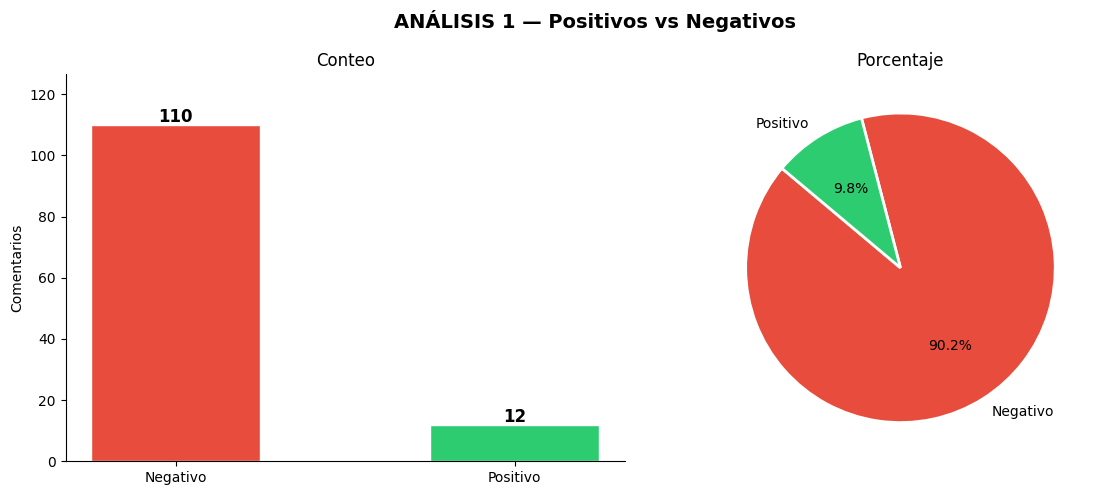

In [15]:
conteo  = df['sentimiento'].value_counts()
colores = ['#2ecc71' if s == 'Positivo' else '#e74c3c' for s in conteo.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ANÁLISIS 1 — Positivos vs Negativos', fontsize=14, fontweight='bold')

bars = axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Comentarios')
axes[0].set_ylim(0, conteo.max() * 1.15)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title('Conteo')

axes[1].pie(conteo.values, labels=conteo.index, colors=colores,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Porcentaje')

plt.tight_layout()
plt.show()

## 7. 🔤 ANÁLISIS 2 — Conteo de Palabras Más Frecuentes

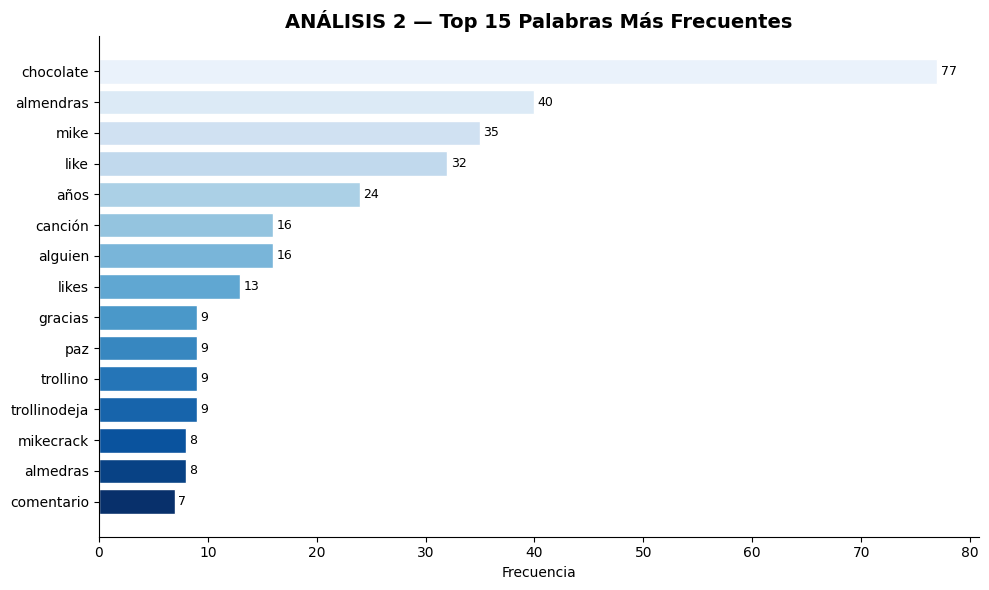

In [16]:
palabras, frecuencias = zip(*top15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(palabras[::-1], frecuencias[::-1],
               color=plt.cm.Blues_r([i/15 for i in range(15)]),
               edgecolor='white')
for bar, val in zip(bars, frecuencias[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('ANÁLISIS 2 — Top 15 Palabras Más Frecuentes', fontsize=14, fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. ⚖️ ANÁLISIS 3 — Palabras en Comentarios Positivos vs Negativos

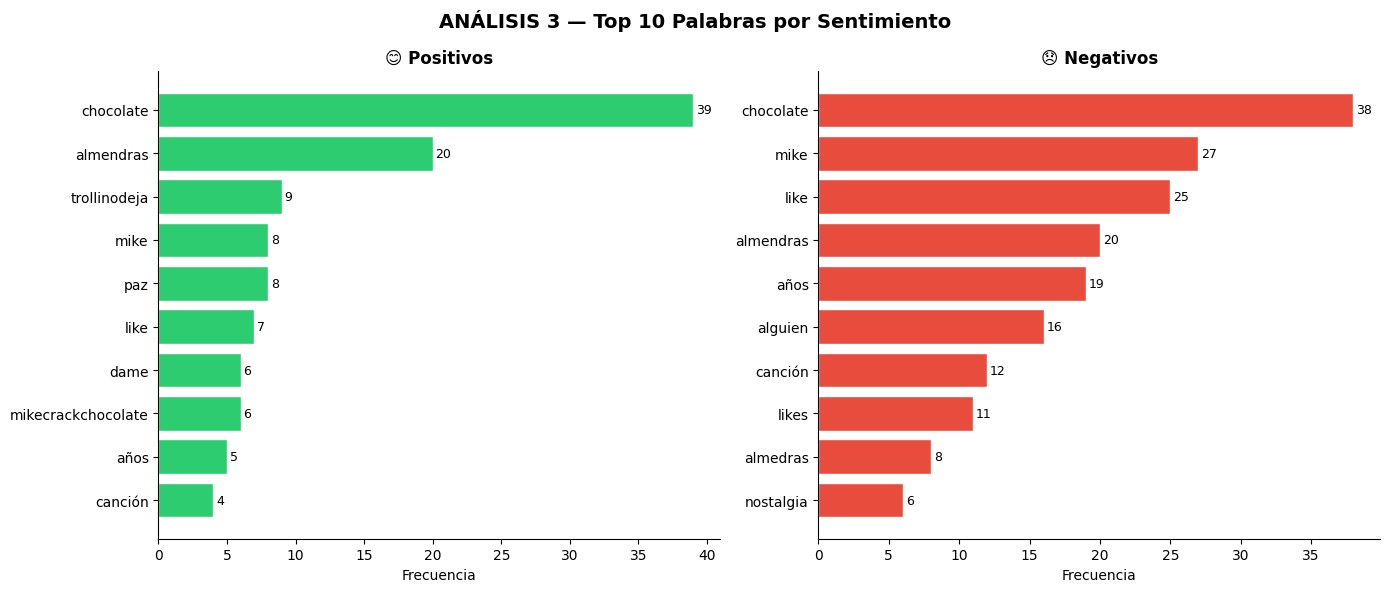

In [17]:
top_pos = Counter(tokens_pos).most_common(10)
top_neg = Counter(tokens_neg).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ANÁLISIS 3 — Top 10 Palabras por Sentimiento', fontsize=14, fontweight='bold')

for ax, top, titulo, color in [
    (axes[0], top_pos, '😊 Positivos', '#2ecc71'),
    (axes[1], top_neg, '😞 Negativos', '#e74c3c')
]:
    if top:
        pals, freqs = zip(*top)
        bars = ax.barh(pals[::-1], freqs[::-1], color=color, edgecolor='white')
        for bar, val in zip(bars, freqs[::-1]):
            ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=9)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 9. ☁️ ANÁLISIS 4 — Nube de Palabras por Sentimiento

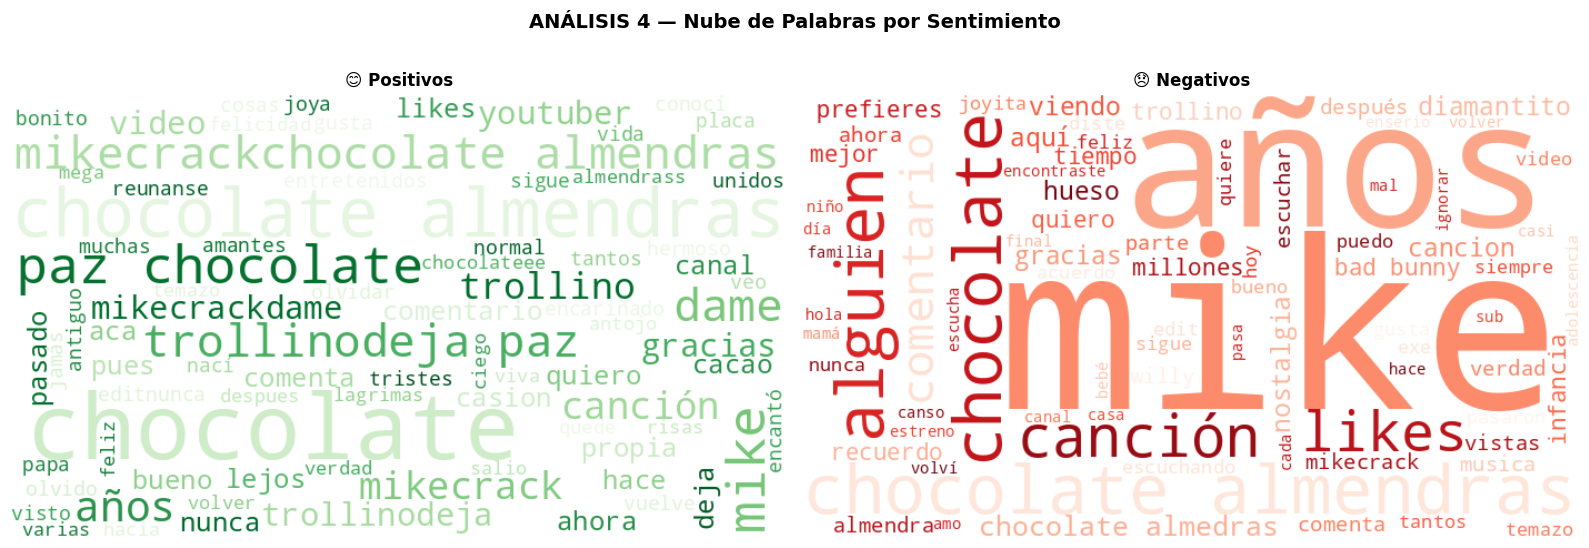

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANÁLISIS 4 — Nube de Palabras por Sentimiento', fontsize=14, fontweight='bold')

for ax, tokens_list, titulo, colormap in [
    (axes[0], tokens_pos, '😊 Positivos', 'Greens'),
    (axes[1], tokens_neg, '😞 Negativos', 'Reds')
]:
    texto_nube = ' '.join(tokens_list) if tokens_list else 'sin datos'
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=colormap, max_words=80).generate(texto_nube)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. 📝 Conclusión Final

In [19]:
total   = len(df)
n_pos   = (df['sentimiento'] == 'Positivo').sum()
n_neg   = (df['sentimiento'] == 'Negativo').sum()
pct_pos = n_pos / total * 100
pct_neg = n_neg / total * 100
pal1    = top15[0][0] if top15 else 'N/A'
pal2    = top15[1][0] if len(top15) > 1 else 'N/A'

if pct_pos >= 60:
    veredicto = 'La audiencia reacciona POSITIVAMENTE al video.'
elif pct_neg >= 60:
    veredicto = 'La audiencia reacciona NEGATIVAMENTE al video.'
else:
    veredicto = 'La audiencia tiene una opinión MIXTA sobre el video.'

print('=' * 55)
print('           CONCLUSIÓN FINAL')
print('=' * 55)
print(f'  Total de comentarios analizados : {total}')
print(f'  Comentarios POSITIVOS           : {n_pos} ({pct_pos:.1f}%)')
print(f'  Comentarios NEGATIVOS           : {n_neg} ({pct_neg:.1f}%)')
print(f'  Palabras más frecuentes         : "{pal1}", "{pal2}"')
print('-' * 55)
print(f'  {veredicto}')
print('=' * 55)

           CONCLUSIÓN FINAL
  Total de comentarios analizados : 122
  Comentarios POSITIVOS           : 12 (9.8%)
  Comentarios NEGATIVOS           : 110 (90.2%)
  Palabras más frecuentes         : "chocolate", "almendras"
-------------------------------------------------------
  La audiencia reacciona NEGATIVAMENTE al video.
